In [65]:
import warnings
warnings.filterwarnings('ignore')

In [66]:
import pandas as pd
import numpy as np
import seaborn as sns

In [67]:
sns.set(rc={'figure.figsize': (11.7, 8.27)})

In [68]:
data = pd.read_csv('data.csv')
data.head(10)

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,5,4,3,4,4,5,25,18.0,False
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,1,5,3,1,1,1,6.0,False
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,5,4,3,4,4,5,0,0.0,True
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,2,5,3,1,2,11,9.0,False
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,5,3,3,4,4,3,3,0,0.0,True
5,Female,Loyal Customer,26,Personal Travel,Eco,1180,3,4,2,1,...,1,1,3,4,4,4,1,0,0.0,False
6,Male,Loyal Customer,47,Personal Travel,Eco,1276,2,4,2,3,...,2,2,3,3,4,3,2,9,23.0,False
7,Female,Loyal Customer,52,Business travel,Business,2035,4,3,4,4,...,5,5,5,5,5,4,4,4,0.0,True
8,Female,Loyal Customer,41,Business travel,Business,853,1,2,2,2,...,3,1,1,2,1,4,2,0,0.0,False
9,Male,disloyal Customer,20,Business travel,Eco,1061,3,3,3,4,...,3,2,2,3,4,4,2,0,0.0,False


In [69]:
from sklearn.model_selection import train_test_split

In [70]:
X = data.drop(columns='satisfaction')
y = data['satisfaction']

In [71]:
data.groupby('Class', as_index=False).agg({'satisfaction': 'mean'})

,Class,satisfaction
0,Business,0.694434
1,Eco,0.187673
2,Eco Plus,0.246414


In [72]:
data.corr(numeric_only=True)['satisfaction']

Age                                  0.134091
Flight Distance                      0.298085
Inflight wifi service                0.283460
Departure/Arrival time convenient   -0.054270
Ease of Online booking               0.168877
Gate location                       -0.002793
Food and drink                       0.211340
Online boarding                      0.501749
Seat comfort                         0.348829
Inflight entertainment               0.398234
On-board service                     0.322205
Leg room service                     0.312424
Baggage handling                     0.248680
Checkin service                      0.237252
Cleanliness                          0.307035
Departure Delay in Minutes          -0.050740
Arrival Delay in Minutes            -0.058275
satisfaction                         1.000000
Name: satisfaction, dtype: float64

In [73]:
data.corr(numeric_only=True)['Inflight entertainment'] 
#заменяет Food and drink Seat comfort Cleanliness

Age                                  0.074947
Flight Distance                      0.130507
Inflight wifi service                0.207802
Departure/Arrival time convenient   -0.008380
Ease of Online booking               0.046564
Gate location                        0.002741
Food and drink                       0.623461
Online boarding                      0.283922
Seat comfort                         0.611837
Inflight entertainment               1.000000
On-board service                     0.418574
Leg room service                     0.300397
Baggage handling                     0.379123
Checkin service                      0.119554
Cleanliness                          0.692511
Departure Delay in Minutes          -0.027012
Arrival Delay in Minutes            -0.030230
satisfaction                         0.398234
Name: Inflight entertainment, dtype: float64

In [74]:
data.corr(numeric_only=True)['Seat comfort'] 

Age                                  0.159136
Flight Distance                      0.157662
Inflight wifi service                0.121513
Departure/Arrival time convenient    0.008666
Ease of Online booking               0.028561
Gate location                        0.002788
Food and drink                       0.575846
Online boarding                      0.419253
Seat comfort                         1.000000
Inflight entertainment               0.611837
On-board service                     0.130545
Leg room service                     0.104272
Baggage handling                     0.074620
Checkin service                      0.189979
Cleanliness                          0.679613
Departure Delay in Minutes          -0.027999
Arrival Delay in Minutes            -0.030521
satisfaction                         0.348829
Name: Seat comfort, dtype: float64

In [75]:
X_train,X_test,y_train,y_test = train_test_split(X, y, random_state=0)
X_y_train = X_train.copy(deep=True)
X_y_train['y'] = y_train

набор данных ['Inflight entertainment' Online boarding Departure/Arrival time convenient Flight Distance Departure Delay in Minutes Arrival Delay in Minutes]

In [76]:
X_y_train.isna().any()

Gender                               False
Customer Type                        False
Age                                  False
Type of Travel                       False
Class                                False
Flight Distance                      False
Inflight wifi service                False
Departure/Arrival time convenient    False
Ease of Online booking               False
Gate location                        False
Food and drink                       False
Online boarding                      False
Seat comfort                         False
Inflight entertainment               False
On-board service                     False
Leg room service                     False
Baggage handling                     False
Checkin service                      False
Cleanliness                          False
Departure Delay in Minutes           False
Arrival Delay in Minutes              True
y                                    False
dtype: bool

In [77]:
X_y_train['Arrival Delay in Minutes'][X_y_train['Arrival Delay in Minutes'].isna() == True]
X_y_train['Arrival Delay in Minutes'] = X_y_train['Arrival Delay in Minutes'].fillna(5)

In [78]:
X_y_train.isna().any()

Gender                               False
Customer Type                        False
Age                                  False
Type of Travel                       False
Class                                False
Flight Distance                      False
Inflight wifi service                False
Departure/Arrival time convenient    False
Ease of Online booking               False
Gate location                        False
Food and drink                       False
Online boarding                      False
Seat comfort                         False
Inflight entertainment               False
On-board service                     False
Leg room service                     False
Baggage handling                     False
Checkin service                      False
Cleanliness                          False
Departure Delay in Minutes           False
Arrival Delay in Minutes             False
y                                    False
dtype: bool

<Axes: xlabel='Online boarding', ylabel='y'>

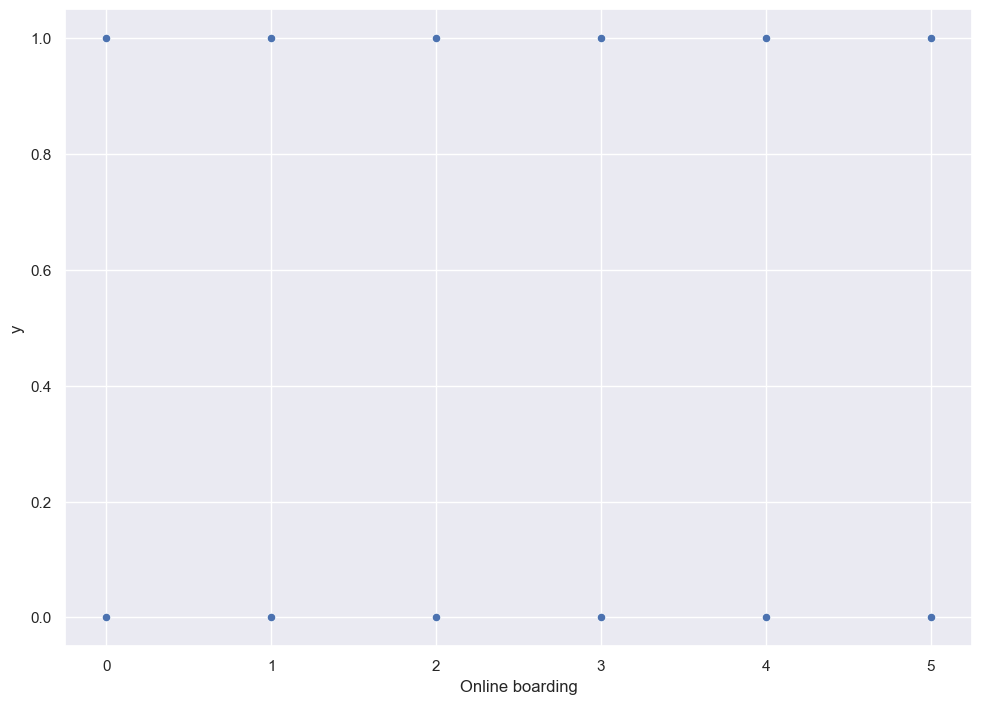

In [79]:
sns.scatterplot(data=X_y_train, x='Online boarding', y='y')

In [80]:
col_x = 'Online boarding'
col_y = 'y'
X_y_train \
    .groupby([col_x, col_y], as_index=False) \
    .agg({'Gender': 'count'}) \
    .pivot(index=col_y, columns=col_x, values='Gender')

Online boarding,0,1,2,3,4,5
y,,,,,,
False,1022,8516,14539,17588,10873,2489
True,1297,1358,1859,2808,18049,17012


In [81]:
X_y_train.corr(numeric_only=True)

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,y
Age,1.000000,0.098764,0.015072,0.035957,0.021483,-0.000824,0.023406,0.208399,0.160770,0.074734,0.057528,0.038206,-0.050065,0.034467,0.054714,-0.008189,-0.010931,0.134074
Flight Distance,0.098764,1.000000,0.004938,-0.018508,0.063436,0.005740,0.055859,0.211447,0.156211,0.128991,0.113503,0.137181,0.067924,0.075491,0.092565,0.003788,-0.000151,0.297777
Inflight wifi service,0.015072,0.004938,1.000000,0.347605,0.715012,0.340091,0.133316,0.458714,0.122114,0.209914,0.121420,0.159570,0.121047,0.043056,0.130730,-0.016020,-0.017754,0.283292
Departure/Arrival time convenient,0.035957,-0.018508,0.347605,1.000000,0.441049,0.447268,-0.000090,0.073178,0.006307,-0.007846,0.067430,0.010224,0.071769,0.089484,0.007722,0.000110,-0.002199,-0.055496
Ease of Online booking,0.021483,0.063436,0.715012,0.441049,1.000000,0.461326,0.031566,0.405302,0.028880,0.048278,0.040310,0.108684,0.040951,0.008252,0.014708,-0.005774,-0.007096,0.169288
Gate location,-0.000824,0.005740,0.340091,0.447268,0.461326,1.000000,-0.002251,0.003700,0.003563,0.004402,-0.028593,-0.004734,0.002078,-0.038156,-0.006263,0.006053,0.005932,-0.002206
Food and drink,0.023406,0.055859,0.133316,-0.000090,0.031566,-0.002251,1.000000,0.234956,0.575119,0.623271,0.059023,0.033797,0.035810,0.083151,0.658304,-0.028073,-0.030628,0.209757
Online boarding,0.208399,0.211447,0.458714,0.073178,0.405302,0.003700,0.234956,1.000000,0.419520,0.284512,0.154184,0.123405,0.083953,0.204052,0.329480,-0.016926,-0.019800,0.503448
Seat comfort,0.160770,0.156211,0.122114,0.006307,0.028880,0.003563,0.575119,0.419520,1.000000,0.612330,0.131799,0.103900,0.074397,0.188156,0.678926,-0.027447,-0.030056,0.348821
Inflight entertainment,0.074734,0.128991,0.209914,-0.007846,0.048278,0.004402,0.623271,0.284512,0.612330,1.000000,0.420629,0.301805,0.379780,0.117699,0.692337,-0.026984,-0.030505,0.396654


In [82]:
numeric_factors = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

In [83]:
categorical_factors = ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
                       'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness']

In [84]:
X_y_train[numeric_factors + ['y']].corr()

,Age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,y
Age,1.000000,0.098764,-0.008189,-0.010931,0.134074
Flight Distance,0.098764,1.000000,0.003788,-0.000151,0.297777
Departure Delay in Minutes,-0.008189,0.003788,1.000000,0.959670,-0.050741
Arrival Delay in Minutes,-0.010931,-0.000151,0.959670,1.000000,-0.057802
y,0.134074,0.297777,-0.050741,-0.057802,1.000000


<Axes: xlabel='Departure Delay in Minutes', ylabel='Arrival Delay in Minutes'>

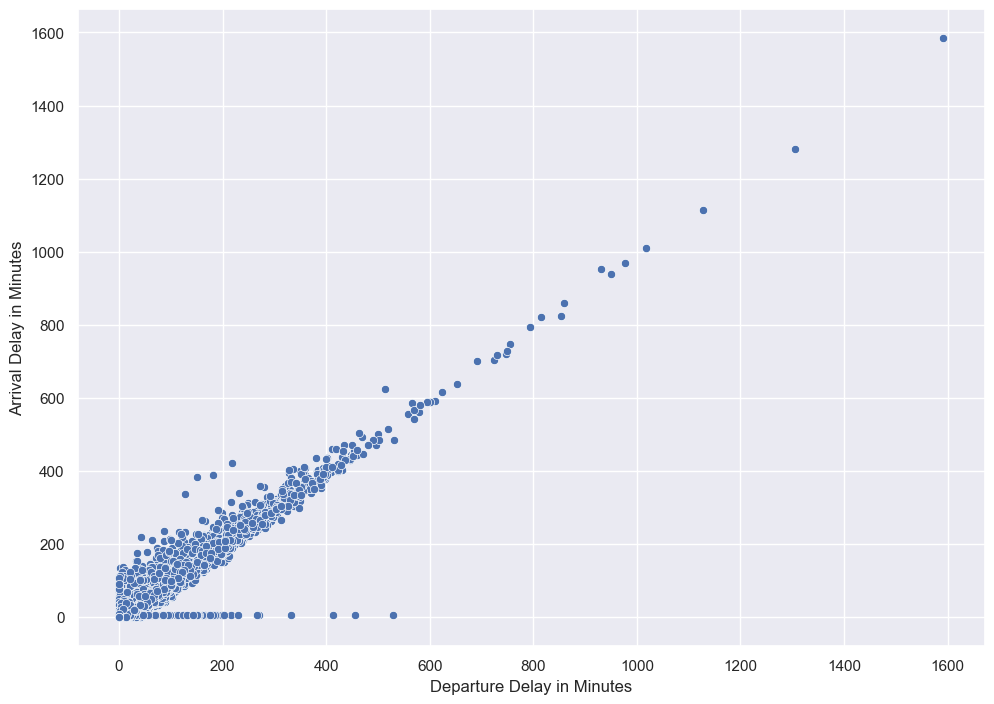

In [85]:
sns.scatterplot(x=X_y_train['Departure Delay in Minutes'], y=X_y_train['Arrival Delay in Minutes'])

In [86]:
X_y_train[X_y_train['Departure Delay in Minutes'] > 60][numeric_factors + ['y']].corr()#почти не влияет

,Age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,y
Age,1.000000,0.095074,-0.018401,-0.023567,0.133101
Flight Distance,0.095074,1.000000,0.049094,0.034809,0.295254
Departure Delay in Minutes,-0.018401,0.049094,1.000000,0.955174,0.006485
Arrival Delay in Minutes,-0.023567,0.034809,0.955174,1.000000,0.008461
y,0.133101,0.295254,0.006485,0.008461,1.000000


In [87]:
X_y_train.groupby('Inflight wifi service',as_index=False).agg({'y':['mean','count']})

Inflight wifi service         y       
                             mean  count
0                     0  0.997626   2949
1                     1  0.329143  16786
2                     2  0.246941  24107
3                     3  0.251605  24145
4                     4  0.600570  18599
5                     5  0.990207  10824

In [88]:
X_y_train.groupby('Gate location',as_index=False).agg({'y':['mean','count']})

Gate location         y       
                     mean  count
0             0  1.000000      1
1             1  0.500212  16511
2             2  0.461761  18293
3             3  0.348404  26719
4             4  0.391249  22740
5             5  0.568234  13146

'Class' 'Customer Type' 'Inflight wifi service' 'Type of Travel' 'Ease of Online booking' 'Inflight entertainment', 'On-board service' 'Food and drink', 'Online boarding' 'Seat comfort' 'Baggage handling', 'Checkin service', 'Cleanliness','Gate location' - factors to use

In [89]:
useful_categorical_factors = ['Class','Customer Type','Inflight wifi service','Type of Travel','Ease of Online booking','Inflight entertainment', 'On-board service','Food and drink', 'Online boarding','Seat comfort','Baggage handling', 'Checkin service', 'Cleanliness','Gate location']

In [90]:
len(useful_categorical_factors)

14

In [91]:
X_y_train[useful_categorical_factors+['y']].corr(numeric_only=True)

,Inflight wifi service,Ease of Online booking,Inflight entertainment,On-board service,Food and drink,Online boarding,Seat comfort,Baggage handling,Checkin service,Cleanliness,Gate location,y
Inflight wifi service,1.000000,0.715012,0.209914,0.121420,0.133316,0.458714,0.122114,0.121047,0.043056,0.130730,0.340091,0.283292
Ease of Online booking,0.715012,1.000000,0.048278,0.040310,0.031566,0.405302,0.028880,0.040951,0.008252,0.014708,0.461326,0.169288
Inflight entertainment,0.209914,0.048278,1.000000,0.420629,0.623271,0.284512,0.612330,0.379780,0.117699,0.692337,0.004402,0.396654
On-board service,0.121420,0.040310,0.420629,1.000000,0.059023,0.154184,0.131799,0.521066,0.247995,0.123528,-0.028593,0.323291
Food and drink,0.133316,0.031566,0.623271,0.059023,1.000000,0.234956,0.575119,0.035810,0.083151,0.658304,-0.002251,0.209757
Online boarding,0.458714,0.405302,0.284512,0.154184,0.234956,1.000000,0.419520,0.083953,0.204052,0.329480,0.003700,0.503448
Seat comfort,0.122114,0.028880,0.612330,0.131799,0.575119,0.419520,1.000000,0.074397,0.188156,0.678926,0.003563,0.348821
Baggage handling,0.121047,0.040951,0.379780,0.521066,0.035810,0.083953,0.074397,1.000000,0.234794,0.096408,0.002078,0.249289
Checkin service,0.043056,0.008252,0.117699,0.247995,0.083151,0.204052,0.188156,0.234794,1.000000,0.172763,-0.038156,0.238373
Cleanliness,0.130730,0.014708,0.692337,0.123528,0.658304,0.329480,0.678926,0.096408,0.172763,1.000000,-0.006263,0.308044


In [92]:
col_x = 'Inflight wifi service'
col_y = 'Ease of Online booking'

X_y_train \
    .groupby([col_x, col_y], as_index=False) \
    .agg({'Gender': 'count'}) \
    .pivot(index=col_y, columns=col_x, values='Gender')

Inflight wifi service,0,1,2,3,4,5
Ease of Online booking,,,,,,
0,2750.0,778.0,291.0,271.0,140.0,53.0
1,194.0,12137.0,1609.0,970.0,978.0,544.0
2,NaN,1260.0,17454.0,1972.0,1157.0,685.0
3,1.0,840.0,2060.0,17596.0,1536.0,685.0
4,1.0,885.0,1352.0,2040.0,13112.0,887.0
5,3.0,886.0,1341.0,1296.0,1676.0,7970.0


In [93]:
excluded_categorical_factors = ['Ease of Online booking', 'Gate location', 'Food and drink', 'Seat comfort', 'Baggage handling', 'Cleanliness']

In [ ]:
useful_numeric_factors = ['Age', 'Flight Distance']
useful_categorical_factors = [i for i in useful_categorical_factors if i not in excluded_categorical_factors]
useful_categorical_factors.append('Gender')
C

['Class',
 'Customer Type',
 'Inflight wifi service',
 'Type of Travel',
 'Inflight entertainment',
 'On-board service',
 'Online boarding',
 'Checkin service',
 'Gender']

In [ ]:
X_y_train_useful_factors = X_y_train[useful_categorical_factors + useful_numeric_factors + ['y']]
X_y_train_useful_factors

,Class,Customer Type,Inflight wifi service,Type of Travel,Inflight entertainment,On-board service,Online boarding,Checkin service,Gender,Age,Flight Distance,y
2049,Eco,Loyal Customer,3,Business travel,3,3,3,3,Male,41,187,False
49176,Eco,disloyal Customer,1,Business travel,4,1,1,2,Male,14,1310,False
38346,Business,Loyal Customer,5,Business travel,4,4,5,4,Female,43,925,True
36699,Eco,Loyal Customer,3,Business travel,3,3,3,1,Male,50,925,False
20521,Eco,Loyal Customer,3,Personal Travel,3,3,2,1,Female,55,460,False
...,...,...,...,...,...,...,...,...,...,...,...,...
45891,Business,Loyal Customer,3,Business travel,5,5,5,2,Male,50,1428,True
117952,Business,Loyal Customer,3,Business travel,5,5,5,4,Male,19,946,True
42613,Eco,Loyal Customer,5,Personal Travel,3,4,5,3,Male,19,493,True
43567,Eco,Loyal Customer,2,Personal Travel,5,5,5,4,Female,69,925,False


In [96]:
from category_encoders import BinaryEncoder, TargetEncoder, OneHotEncoder

In [97]:
gender_encoder = BinaryEncoder()
gender_encoder.fit(X_y_train_useful_factors['Gender'])

,verbose,0
,cols,['Gender']
,mapping,"[{'col': 'Gender', 'mapping': Gender_0 ... 0 0}]"
,drop_invariant,False
,return_df,True
,base,2
,handle_unknown,'value'
,handle_missing,'value'


In [98]:
gender_encoder.transform(X_y_train_useful_factors['Gender'])

,Gender_0,Gender_1
2049,0,1
49176,0,1
38346,1,0
36699,0,1
20521,1,0
...,...,...
45891,0,1
117952,0,1
42613,0,1
43567,1,0


In [99]:
gender_type_of_travel_encoder = BinaryEncoder()
gender_type_of_travel_encoder.fit(X_y_train_useful_factors[['Gender','Type of Travel']])
gender_type_of_travel_encoded = gender_type_of_travel_encoder.transform(X_y_train_useful_factors[['Gender','Type of Travel']])
for col in gender_type_of_travel_encoded:
    X_y_train_useful_factors[col] = gender_type_of_travel_encoded[col]
    
X_y_train_useful_factors = X_y_train_useful_factors.drop(columns=['Gender', 'Type of Travel'])
X_y_train_useful_factors

,Class,Customer Type,Inflight wifi service,Inflight entertainment,On-board service,Online boarding,Checkin service,Age,Flight Distance,y,Gender_0,Gender_1,Type of Travel_0,Type of Travel_1
2049,Eco,Loyal Customer,3,3,3,3,3,41,187,False,0,1,0,1
49176,Eco,disloyal Customer,1,4,1,1,2,14,1310,False,0,1,0,1
38346,Business,Loyal Customer,5,4,4,5,4,43,925,True,1,0,0,1
36699,Eco,Loyal Customer,3,3,3,3,1,50,925,False,0,1,0,1
20521,Eco,Loyal Customer,3,3,3,2,1,55,460,False,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45891,Business,Loyal Customer,3,5,5,5,2,50,1428,True,0,1,0,1
117952,Business,Loyal Customer,3,5,5,5,4,19,946,True,0,1,0,1
42613,Eco,Loyal Customer,5,3,4,5,3,19,493,True,0,1,1,0
43567,Eco,Loyal Customer,2,5,5,5,4,69,925,False,1,0,1,0


In [100]:
target_encoded_categories = [x for x in useful_categorical_factors if x not in ['Gender', 'Type of Travel']]

In [101]:
for col in target_encoded_categories:
    X_y_train_useful_factors[col] = X_y_train_useful_factors[col].astype('category')

In [102]:
X_y_train_useful_factors.dtypes

Class                     category
Customer Type             category
Inflight wifi service     category
Inflight entertainment    category
On-board service          category
Online boarding           category
Checkin service           category
Age                          int64
Flight Distance              int64
y                             bool
Gender_0                     int64
Gender_1                     int64
Type of Travel_0             int64
Type of Travel_1             int64
dtype: object

In [103]:
target_encoder = TargetEncoder()
target_encoder.fit(X_y_train_useful_factors[target_encoded_categories],y=X_y_train_useful_factors['y'])

,verbose,0
,cols,"['Class', 'Customer Type', ...]"
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,min_samples_leaf,20
,smoothing,10
,hierarchy,None


In [104]:
target_encoder.transform(X_y_train_useful_factors[target_encoded_categories])

,Class,Customer Type,Inflight wifi service,Inflight entertainment,On-board service,Online boarding,Checkin service
2049,0.188327,0.478736,0.251605,0.273650,0.316771,0.137674,0.448453
49176,0.188327,0.240164,0.329143,0.610346,0.196860,0.137533,0.250846
38346,0.694691,0.478736,0.990207,0.610346,0.536111,0.872366,0.460151
36699,0.188327,0.478736,0.251605,0.273650,0.316771,0.137674,0.242364
20521,0.188327,0.478736,0.251605,0.273650,0.316771,0.113367,0.242364
...,...,...,...,...,...,...,...
45891,0.694691,0.478736,0.251605,0.650755,0.648188,0.872366,0.250846
117952,0.694691,0.478736,0.251605,0.650755,0.648188,0.872366,0.460151
42613,0.188327,0.478736,0.990207,0.273650,0.536111,0.872366,0.448453
43567,0.188327,0.478736,0.246941,0.650755,0.648188,0.872366,0.460151


In [105]:
X_y_train_useful_factors.groupby('Customer Type').agg({'y':'mean'})

,y
Customer Type,
Loyal Customer,0.478736
disloyal Customer,0.240164


In [106]:
categorical_factors_encoded = target_encoder.transform(X_y_train_useful_factors[target_encoded_categories])
for col in categorical_factors_encoded:
    X_y_train_useful_factors[col] = categorical_factors_encoded[col]
X_y_train_useful_factors

,Class,Customer Type,Inflight wifi service,Inflight entertainment,On-board service,Online boarding,Checkin service,Age,Flight Distance,y,Gender_0,Gender_1,Type of Travel_0,Type of Travel_1
2049,0.188327,0.478736,0.251605,0.273650,0.316771,0.137674,0.448453,41,187,False,0,1,0,1
49176,0.188327,0.240164,0.329143,0.610346,0.196860,0.137533,0.250846,14,1310,False,0,1,0,1
38346,0.694691,0.478736,0.990207,0.610346,0.536111,0.872366,0.460151,43,925,True,1,0,0,1
36699,0.188327,0.478736,0.251605,0.273650,0.316771,0.137674,0.242364,50,925,False,0,1,0,1
20521,0.188327,0.478736,0.251605,0.273650,0.316771,0.113367,0.242364,55,460,False,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45891,0.694691,0.478736,0.251605,0.650755,0.648188,0.872366,0.250846,50,1428,True,0,1,0,1
117952,0.694691,0.478736,0.251605,0.650755,0.648188,0.872366,0.460151,19,946,True,0,1,0,1
42613,0.188327,0.478736,0.990207,0.273650,0.536111,0.872366,0.448453,19,493,True,0,1,1,0
43567,0.188327,0.478736,0.246941,0.650755,0.648188,0.872366,0.460151,69,925,False,1,0,1,0


In [107]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [108]:
scaler.fit(X_y_train_useful_factors.drop(columns='y'))

,copy,True
,with_mean,True
,with_std,True


In [109]:
X_y_train_useful_factors[X_y_train_useful_factors.drop(columns='y').columns] = \
    scaler.transform(X_y_train_useful_factors.drop(columns='y'))

In [110]:
X_y_train_useful_factors

,Class,Customer Type,Inflight wifi service,Inflight entertainment,On-board service,Online boarding,Checkin service,Age,Flight Distance,y,Gender_0,Gender_1,Type of Travel_0,Type of Travel_1
2049,-0.991014,0.473129,-0.703202,-0.776461,-0.715252,-0.969222,0.107145,0.103861,-1.005799,False,-1.016020,1.016020,-0.669201,0.669201
49176,-0.991014,-2.113587,-0.406052,0.842415,-1.439955,-0.969682,-1.478325,-1.680678,0.120675,False,-1.016020,1.016020,-0.669201,0.669201
38346,1.042498,0.473129,2.127330,0.842415,0.610374,1.424925,0.200998,0.236049,-0.265516,True,0.984233,-0.984233,-0.669201,0.669201
36699,-0.991014,0.473129,-0.703202,-0.776461,-0.715252,-0.969222,-1.546384,0.698707,-0.265516,False,-1.016020,1.016020,-0.669201,0.669201
20521,-0.991014,0.473129,-0.703202,-0.776461,-0.715252,-1.048430,-1.546384,1.029177,-0.731955,False,0.984233,-0.984233,1.494319,-1.494319
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45891,1.042498,0.473129,-0.703202,1.036710,1.287738,1.424925,-1.478325,0.698707,0.239040,True,-1.016020,1.016020,-0.669201,0.669201
117952,1.042498,0.473129,-0.703202,1.036710,1.287738,1.424925,0.200998,-1.350208,-0.244451,True,-1.016020,1.016020,-0.669201,0.669201
42613,-0.991014,0.473129,2.127330,-0.776461,0.610374,1.424925,0.107145,-1.350208,-0.698853,True,-1.016020,1.016020,1.494319,-1.494319
43567,-0.991014,0.473129,-0.721076,1.036710,1.287738,1.424925,0.200998,1.954494,-0.265516,False,0.984233,-0.984233,1.494319,-1.494319


In [111]:
X_train = X_y_train_useful_factors.drop(columns='y')

In [112]:
from sklearn.linear_model import LogisticRegression

In [113]:
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train, random_state=1000)

In [114]:
model = LogisticRegression()

In [115]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [116]:
model.predict(X_train)

array([ True,  True,  True, ...,  True, False, False], shape=(73057,))

In [117]:
model.predict_proba(X_train)

array([[0.00222715, 0.99777285],
       [0.0015883 , 0.9984117 ],
       [0.00772848, 0.99227152],
       ...,
       [0.20408168, 0.79591832],
       [0.52198824, 0.47801176],
       [0.99870608, 0.00129392]], shape=(73057, 2))

In [118]:
model.score(X_train, y_train)

0.9178723462501882

In [119]:
from sklearn.metrics import f1_score, accuracy_score, precision_score,recall_score

In [120]:
accuracy_score(y_train,model.predict(X_train))

0.9178723462501882

In [121]:
precision_score(y_train,model.predict(X_train))

0.9064224233061134

In [122]:
recall_score(y_train, model.predict(X_train))

0.9045970863094301

In [123]:
f1_score(y_train, model.predict(X_train))

0.9055088349239346

In [124]:
accuracy_score(y_val,model.predict(X_val))

0.9184494723442697

In [128]:
best_treshold = None
best_f1 = -float('inf')
probabilities = model.predict_proba(X_val)[:,1]
for t in range(1000):
    treshold = 0.001*t

    y_val_pred = treshold < probabilities
    f1 = f1_score(y_val, y_val_pred)
    if f1>best_f1:
        best_f1 = f1
        best_treshold = treshold



In [129]:
best_f1, best_treshold

(0.9094506303487623, 0.388)

In [ ]:
 = X_test[useful_categorical_factors + useful_numeric_factors]X_test_useful_factors

In [133]:

gender_type_of_travel_encoded = gender_type_of_travel_encoder.transform(X_test_useful_factors[['Gender','Type of Travel']])
for col in gender_type_of_travel_encoded:
    X_test_useful_factors[col] = gender_type_of_travel_encoded[col]
X_test_useful_factors = X_test_useful_factors.drop(columns=['Gender','Type of Travel'])

In [134]:
categorial_factors_encoded = target_encoder.transform(X_test_useful_factors[target_encoded_categories])
for col in categorial_factors_encoded:
    X_test_useful_factors[col]=categorial_factors_encoded[col]

In [135]:
X_test_useful_factors[X_test_useful_factors.columns] = scaler.transform(X_test_useful_factors)

In [136]:
X_test_useful_factors

,Class,Customer Type,Inflight wifi service,Inflight entertainment,On-board service,Online boarding,Checkin service,Age,Flight Distance,Gender_0,Gender_1,Type of Travel_0,Type of Travel_1
125669,-0.991014,0.473129,-0.703202,-1.055199,-1.075463,-0.969222,0.107145,-1.878960,-1.137205,-1.016020,1.016020,1.494319,-1.494319
90648,1.042498,0.473129,-0.703202,0.842415,0.610374,0.615762,0.200998,0.632613,1.488894,-1.016020,1.016020,-0.669201,0.669201
45322,-0.991014,0.473129,0.634131,0.842415,-0.715252,0.615762,0.200998,0.830895,0.609181,-1.016020,1.016020,-0.669201,0.669201
64084,1.042498,0.473129,2.127330,-1.407441,0.610374,-1.048430,-1.546384,-0.755362,-0.511274,-1.016020,1.016020,-0.669201,0.669201
71595,-0.991014,0.473129,0.634131,0.842415,0.610374,-0.969682,-1.546384,0.963083,-0.859348,0.984233,-0.984233,1.494319,-1.494319
...,...,...,...,...,...,...,...,...,...,...,...,...,...
127886,1.042498,0.473129,0.634131,0.842415,0.610374,-0.969682,-1.478325,0.566519,2.643455,0.984233,-0.984233,-0.669201,0.669201
37272,1.042498,0.473129,-0.721076,1.036710,1.287738,1.424925,1.449067,0.896989,0.504860,-1.016020,1.016020,-0.669201,0.669201
36325,-0.991014,0.473129,2.127330,1.036710,-0.715252,1.424925,-1.478325,-0.557080,-0.884425,-1.016020,1.016020,1.494319,-1.494319
75258,1.042498,-2.113587,-0.406052,-1.407441,-0.715252,-0.969682,1.449067,-0.689268,-0.980722,0.984233,-0.984233,-0.669201,0.669201


In [137]:
print('Accuracy на тестовой выборке:', accuracy_score(y_test, model.predict(X_test_useful_factors)))
print('Precision на тестовой выборке:', precision_score(y_test, model.predict(X_test_useful_factors)))
print('Recall на тестовой выборке:', recall_score(y_test, model.predict(X_test_useful_factors)))

Accuracy на тестовой выборке: 0.91749307052664
Precision на тестовой выборке: 0.9056967447173044
Recall на тестовой выборке: 0.903310786756853


In [146]:
boot_ac = []
boot_prec=[]
boot_recall =[]
X_y_test = X_test_useful_factors.copy(deep=True)
X_y_test['y'] = y_test
for i in range(1000):
    X_y_test_boot = X_y_test.sample(len(X_y_test), replace=True)
    y_test_boot = X_y_test_boot['y']
    X_y_test_boot = X_y_test_boot.drop(columns='y')
    predicted_probas = model.predict_proba(X_y_test_boot)
    y_pred = predicted_probas[:, 1] >= best_treshold
    
    boot_ac.append(accuracy_score(y_test_boot, y_pred))
    boot_prec.append(precision_score(y_test_boot, y_pred))
    boot_recall.append(recall_score(y_test_boot, y_pred))


<Axes: ylabel='Count'>

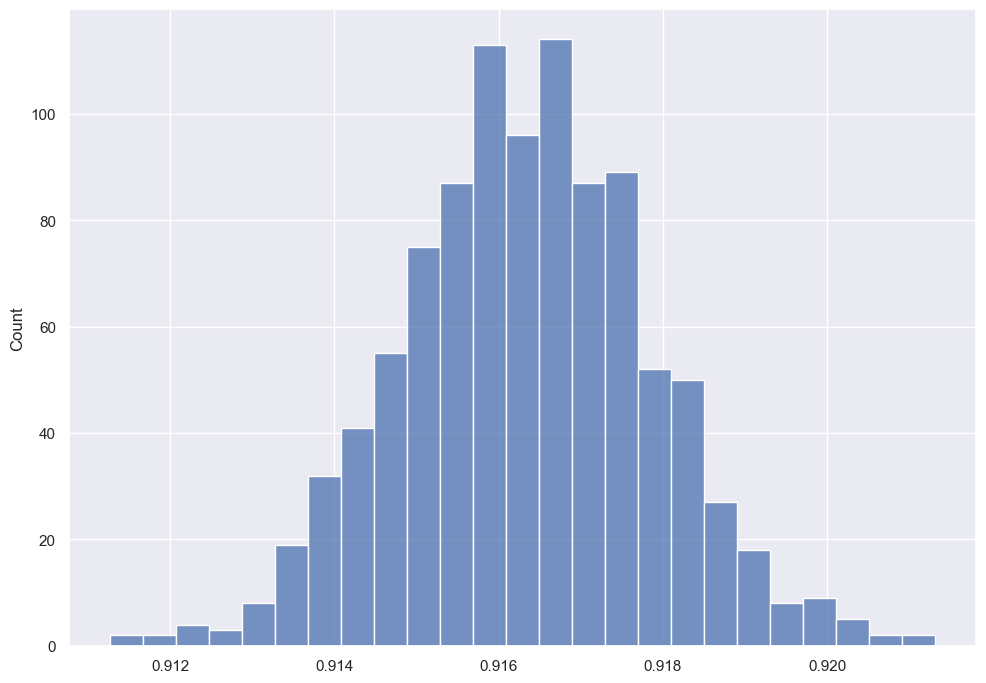

In [148]:
sns.histplot(boot_ac)

In [150]:
boot_accuracies_sorted = list(sorted(boot_ac))
boot_accuracies_sorted = boot_accuracies_sorted[25:975]

print('Доверительный интервал для accuracy:', 
      '(' + str(round(boot_accuracies_sorted[0], 3)) + ', ' + str(round(boot_accuracies_sorted[-1], 3)) + ')')

Доверительный интервал для accuracy: (0.913, 0.919)


In [153]:
boot_precisions_sorted = list(sorted(boot_prec))
boot_precisions_sorted = boot_precisions_sorted[25:975]

print('Доверительный интервал для precision:', 
      '(' + str(round(boot_precisions_sorted[0], 3)) + ', ' + str(round(boot_precisions_sorted[-1], 3)) + ')')

Доверительный интервал для precision: (0.88, 0.89)


In [152]:
boot_recalls_sorted = list(sorted(boot_recall))
boot_recalls_sorted = boot_recalls_sorted[25:975]

print('Доверительный интервал для recall:', 
      '(' + str(round(boot_recalls_sorted[0], 3)) + ', ' + str(round(boot_recalls_sorted[-1], 3)) + ')')

Доверительный интервал для recall: (0.922, 0.93)


In [154]:
len(X_y_test)

32470

In [155]:
model.coef_

array([[ 5.77081133e-01,  1.02365487e+00,  1.75873148e+00,
         3.80992373e-01,  5.81773339e-01,  1.05333972e+00,
         5.71645656e-01, -5.22654775e-02,  5.77160852e-02,
        -1.27073770e-03,  1.27073770e-03, -7.91707266e-01,
         7.91707266e-01]])